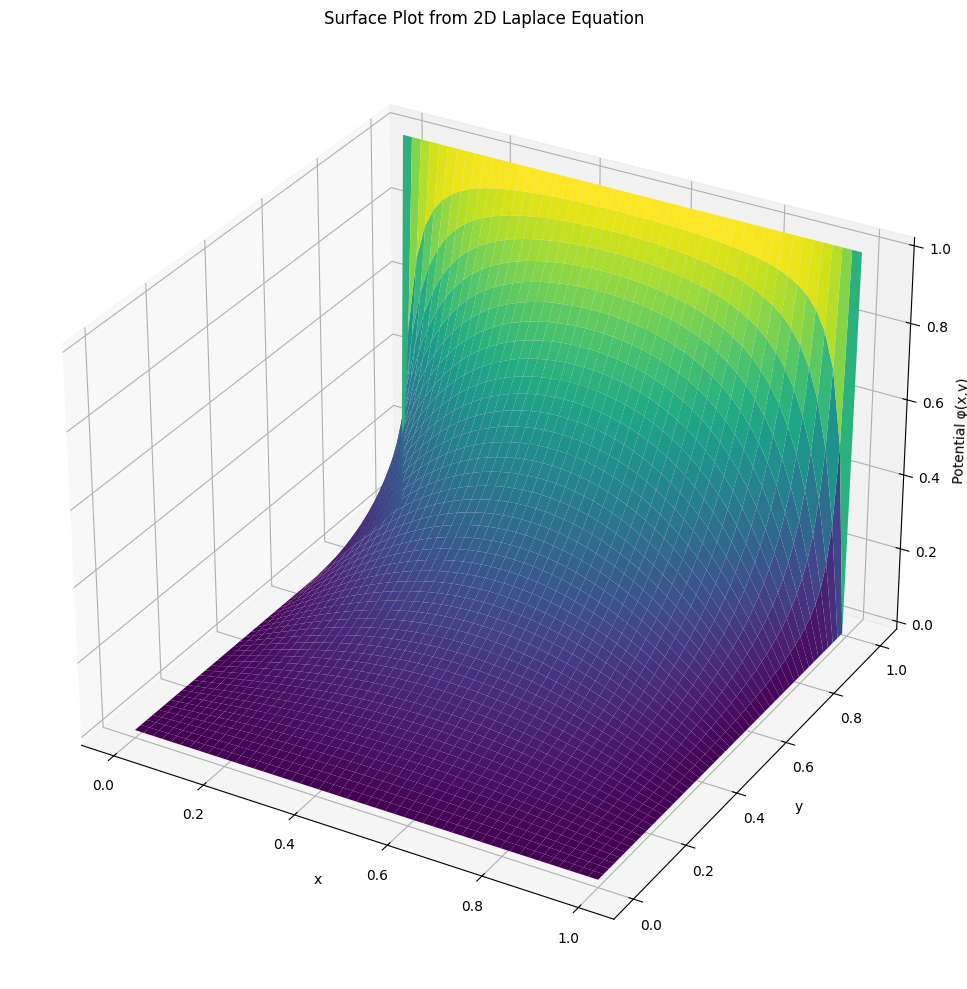

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
phi = np.loadtxt('laplace.dat')  # Adjust filename

# Get grid size from phi itself
Nx, Ny = phi.shape

# Create matching grid
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
X, Y = np.meshgrid(x, y)

# Plotting
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, phi.T, cmap='viridis')  # Transpose if needed
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Potential φ(x,y)')
ax.set_title('Surface Plot from 2D Laplace Equation')

plt.tight_layout()
plt.show()


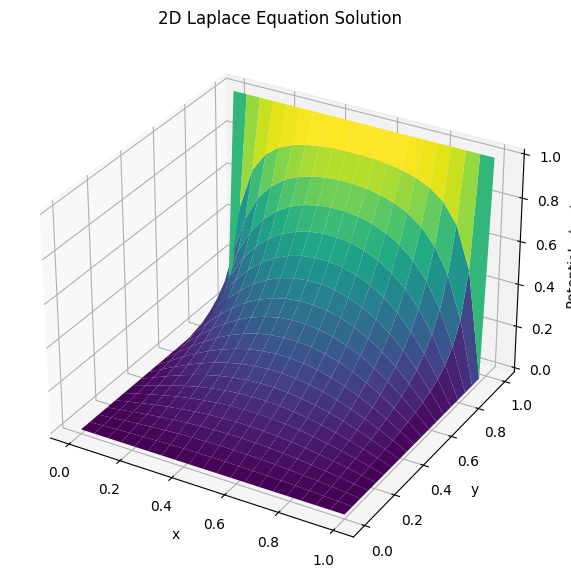

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
N = 20  # number of grid points
tolerance = 1e-5

# Create grid
phi = np.zeros((N, N))
phi[:, -1] = 1  # Top side y=1 set to 1

# Discretization step
h = 1.0 / (N - 1)
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

# Iterative solver (Gauss-Seidel method)
error = 1.0
while error > tolerance:
    old_phi = phi.copy()

    for i in range(1, N-1):
        for j in range(1, N-1):
            phi[i, j] = 0.25 * (phi[i+1, j] + phi[i-1, j] + phi[i, j+1] + phi[i, j-1])

    error = np.max(np.abs(phi - old_phi))

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, phi.T, cmap='viridis')  # Note: transpose phi to match x-y axes
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Potential φ(x,y)')
ax.set_title('2D Laplace Equation Solution')

plt.show()
